Title: LEE_Detection_future.ipynb

Purpose: Identifiy Low Energy Events with varying lengths from the model output data under warming conditions

Author: Onno Nennecke on 21.03.2025 Modified: 24.02.2026

Input data: 

- adjusted final model output
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'

Output data:

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob


### Read Model output data

In [3]:
# path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
# path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'

ts_datasets = xr.open_dataset(path)
ts_datasets.load()

<xarray.Dataset> Size: 59MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    wind_off_prod  (ESM_run, time) float64 6MB 92.24 77.15 30.34 ... 166.3 147.1
    wind_on_prod   (ESM_run, time) float64 6MB 153.1 321.4 ... 539.8 1.166e+03
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73

In [52]:
# path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/'
# files = sorted(glob.glob(path + '*.nc'))
# # files = files[:60] + files[61:]
# ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim = 'ESM_run')
# ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))

# ts_datasets

#### Identification of low energy events

In [4]:
# RL = ts_datasets['Residual_load_adj']
RL = ts_datasets['Residual_load']

RL.values

array([[1221.20013817, 1071.59187726, 1250.71236328, ..., 1124.18602803,
        1314.31349002, 1291.64656601],
       [1236.05905651, 1028.26014001,  859.23223506, ..., 1200.41834566,
        1364.94718233, 1281.12595676],
       [ 958.52142067,  762.15764943,  424.02704545, ...,  993.32481832,
         955.29524753,  721.85881236],
       ...,
       [  -6.01077866,  382.37037722,  319.39666533, ...,  948.5305033 ,
         523.1708532 ,  580.68592875],
       [1544.47081279, 1272.66468121,  766.56365913, ...,  989.08750978,
        1239.88797735,  934.47109452],
       [ 131.16803645,  280.03751942,  555.75631081, ..., 1106.66151732,
         674.92395871,   71.73037994]])

In [5]:
# Calculate the rolling means
ts_datasets['RL_mov_avg_7'] = RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
ts_datasets['RL_mov_avg_14'] = RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()
# ts_datasets

In [6]:
ts_datasets.load()

<xarray.Dataset> Size: 70MB
Dimensions:        (ESM_run: 192, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         <U4 16B 'week'
  * time           (time) datetime64[ns] 29kB 2039-01-01 ... 2048-12-31
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables: (12/14)
    temp           (ESM_run, time) float64 6MB 1.208 -0.303 ... 6.245 7.776
    demand         (ESM_run, time) float64 6MB 1.505e+03 1.524e+03 ... 1.422e+03
    sfcWind        (ESM_run, time) float64 6MB 4.406 6.058 5.642 ... 6.601 8.858
    rsds           (ESM_run, time) float32 3MB 23.72 30.12 26.28 ... 32.49 20.75
    tas            (ESM_run, time) float32 3MB 1.553 0.233 ... 6.191 7.687
    tasmax         (ESM_run, time) float32 3MB 2.524 1.048 ... 9.226 9.364
    ...             ...
    solar_prod     (ESM_run, time) float64 6MB 38.47 53.53 46.18 ... 61.05 37.61
    total_prod     (ESM_run, time) float64 6MB 283.8 452.1 ... 767.1 1.351e+03
    Netto          (ESM_run, time) float64 6MB -1.221e+03 -1.072e+03 ... -71.73
    Residual_load  (ESM_run, time) float64 6MB 1.221e+03 1.072e+03 ... 71.73
    RL_mov_avg_7   (ESM_run, time) float64 6MB nan nan nan ... 380.5 484.8 507.2
    RL_mov_avg_14  (ESM_run, time) float64 6MB nan nan nan ... 421.0 406.6 315.0

##### Threshold Calculation

In [7]:
thresh_perc = 0.95

In [9]:
# Select all ESM_runs with period 'week'
ts_datasets_week = ts_datasets.copy()
# RL_week = ts_datasets_week['Residual_load_adj']
RL_week = ts_datasets_week['Residual_load']
threshold_week = np.quantile(RL_week.values.flatten(), thresh_perc)
threshold_week

np.float64(1310.5234128393997)

### Use threshold from earlier time period

In [13]:
threshold_week = np.float64(1319.1588066525014)

threshold_week

np.float64(1319.1588066525014)

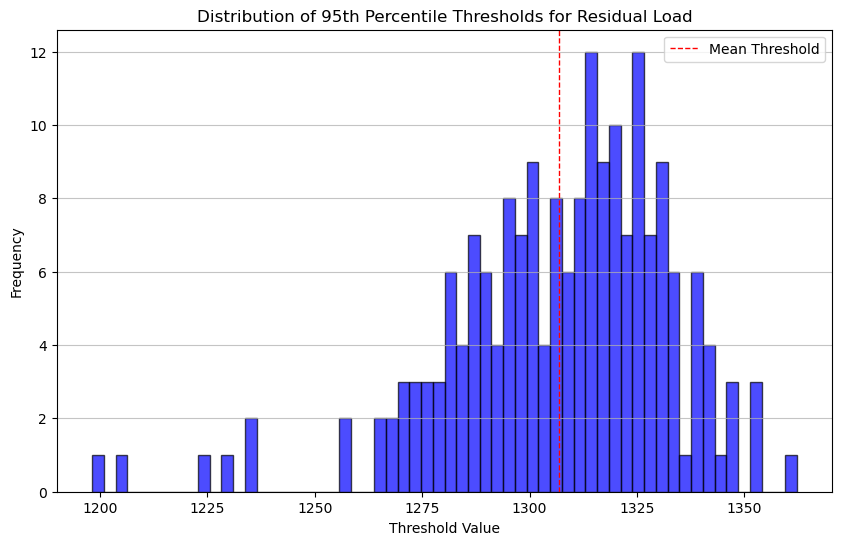

In [10]:
# Test
threshs = []
for esm_run in ts_datasets.ESM_run.values:
    ts_datasets_tst = ts_datasets.sel(ESM_run=esm_run)
    # RL_tst = ts_datasets_tst['Residual_load_adj']
    RL_tst = ts_datasets_tst['Residual_load']
    threshold_tst = np.quantile(RL_tst.values.flatten(), thresh_perc)
    threshs.append(threshold_tst)

# Plot the thresholds as a distribution
plt.figure(figsize=(10, 6))
plt.hist(threshs, bins=60, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of 95th Percentile Thresholds for Residual Load')
plt.xlabel('Threshold Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.axvline(np.mean(threshs), color='red', linestyle='dashed', linewidth=1, label='Mean Threshold')
plt.legend()
plt.show()

In [14]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool_1 = xr.where(RL > threshold_week, True, False)
exceed_bool_7 = xr.where(RL_mov_avg_7 > threshold_week, True, False)
exceed_bool_14 = xr.where(RL_mov_avg_14 > threshold_week, True, False)

In [15]:
# Look for events without any rolling mean


# Count number of true values overall
count_exceed_1 = exceed_bool_1.sum(dim='time').sum(dim='ESM_run')
count_exceed_1.values
# exceed_bool_1.time
# np.zeros_like(exceed_bool_1, dtype=int)

array(31661)

### Days above threshold (dat) 

- Take each day as its own event (not really events but just days above threshold)

In [16]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_1.values)
n_dat = run_idx.size

# 2) Create a flat counter 1…n_dat
labels = np.arange(1, n_dat + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat = np.zeros_like(exceed_bool_1.values, dtype=int)
dat[run_idx, time_idx] = labels

# wrap back into an xarray
dat = xr.DataArray(
    dat,
    coords=exceed_bool_1.coords,
    dims=exceed_bool_1.dims,
    name="dat"
)

n_dat = n_dat
dat

<xarray.DataArray 'dat' (ESM_run: 192, time: 3650)> Size: 6MB
array([[    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,   378,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       ...,
       [    0,     0,     0, ...,     0,     0,     0],
       [31205,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    <U4 16B 'week'
  * time      (time) datetime64[ns] 29kB 2039-01-01 2039-01-02 ... 2048-12-31
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [17]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_7.values)
n_dat_7 = run_idx.size

# 2) Create a flat counter 1…n_dat_7
labels = np.arange(1, n_dat_7 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_7 = np.zeros_like(exceed_bool_7.values, dtype=int)
dat_7[run_idx, time_idx] = labels

# wrap back into an xarray
dat_7 = xr.DataArray(
    dat_7,
    coords=exceed_bool_7.coords,
    dims=exceed_bool_7.dims,
    name="dat_7"
)

n_dat_7 = n_dat_7
dat_7

<xarray.DataArray 'dat_7' (ESM_run: 192, time: 3650)> Size: 6MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    <U4 16B 'week'
  * time      (time) datetime64[ns] 29kB 2039-01-01 2039-01-02 ... 2048-12-31
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [18]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_14.values)
n_dat_14 = run_idx.size

# 2) Create a flat counter 1…n_dat_14
labels = np.arange(1, n_dat_14 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_14 = np.zeros_like(exceed_bool_14.values, dtype=int)
dat_14[run_idx, time_idx] = labels

# wrap back into an xarray
dat_14 = xr.DataArray(
    dat_14,
    coords=exceed_bool_14.coords,
    dims=exceed_bool_14.dims,
    name="dat_14"
)

n_dat_14 = n_dat_14
dat_14

<xarray.DataArray 'dat_14' (ESM_run: 192, time: 3650)> Size: 6MB
array([[ 0,  0,  0, ..., 17, 18, 19],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r7i1p1f2' 'r8i1p1f2'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1...
    country   float64 8B 9.0
    period    <U4 16B 'week'
  * time      (time) datetime64[ns] 29kB 2039-01-01 2039-01-02 ... 2048-12-31
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

### Events with rolling mean of 1 above threshold (events_vl) = events with varying length 

In [19]:
# Look for events without any rolling mean

events_vl = np.zeros_like(exceed_bool_1, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
for run in exceed_bool_1.ESM_run.values:
    run_data = exceed_bool_1.sel(ESM_run=run)
    # Only label this section
    labeled_segment, num_features = ndimage.label(run_data.values)

    if num_features > 0:
        labeled_segment[labeled_segment > 0] += current_label - 1
        current_label += num_features

    # Save the label to the result array
    events_vl[counter] = labeled_segment
    counter += 1

n_events_vl = current_label - 1
n_events_vl



15695

In [20]:
def LEE_detection(events, n_events, t=RL['time'].values, dur = 7, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue
            print(f"Processing event {ev} for run {i+1}/{len(RL.ESM_run)}")

            end_idx = np.where(events[i] == ev)[0][0]
            start_idx = end_idx - dur + 1

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM[i].values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)


In [21]:
LEE_dat = LEE_detection(dat, n_dat, dur = 1)

Processing event 1 for run 1/192
Processing event 2 for run 1/192
Processing event 3 for run 1/192
Processing event 4 for run 1/192
Processing event 5 for run 1/192
Processing event 6 for run 1/192
Processing event 7 for run 1/192
Processing event 8 for run 1/192
Processing event 9 for run 1/192
Processing event 10 for run 1/192
Processing event 11 for run 1/192
Processing event 12 for run 1/192
Processing event 13 for run 1/192
Processing event 14 for run 1/192
Processing event 15 for run 1/192
Processing event 16 for run 1/192
Processing event 17 for run 1/192
Processing event 18 for run 1/192
Processing event 19 for run 1/192
Processing event 20 for run 1/192
Processing event 21 for run 1/192
Processing event 22 for run 1/192
Processing event 23 for run 1/192
Processing event 24 for run 1/192
Processing event 25 for run 1/192
Processing event 26 for run 1/192
Processing event 27 for run 1/192
Processing event 28 for run 1/192
Processing event 29 for run 1/192
Processing event 30 for

In [22]:
LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_fut.csv', index=False)
# LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat.csv', index=False)

LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2039-01-25,2039-01-25,2039-01-25,24,24,24,1,1353.514569,1353.514569,0.0,1353.514569,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,25
1,2039-02-20,2039-02-20,2039-02-20,50,50,50,1,1353.209352,1353.209352,0.0,1353.209352,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,51
2,2039-02-21,2039-02-21,2039-02-21,51,51,51,1,1340.235724,1340.235724,0.0,1340.235724,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,52
3,2039-02-22,2039-02-22,2039-02-22,52,52,52,1,1331.586276,1331.586276,0.0,1331.586276,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,53
4,2039-03-10,2039-03-10,2039-03-10,68,68,68,1,1331.123257,1331.123257,0.0,1331.123257,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,69
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31656,2048-11-21,2048-11-21,2048-11-21,3609,3609,3609,1,1350.057521,1350.057521,0.0,1350.057521,31657,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,325
31657,2048-11-25,2048-11-25,2048-11-25,3613,3613,3613,1,1328.704265,1328.704265,0.0,1328.704265,31658,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,329
31658,2048-12-02,2048-12-02,2048-12-02,3620,3620,3620,1,1419.256919,1419.256919,0.0,1419.256919,31659,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,336
31659,2048-12-09,2048-12-09,2048-12-09,3627,3627,3627,1,1421.787188,1421.787188,0.0,1421.787188,31660,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,343


In [23]:
LEE_dat_7 = LEE_detection(dat_7, n_dat_7, dur = 7)

Processing event 1 for run 1/192
Processing event 2 for run 1/192
Processing event 3 for run 1/192
Processing event 4 for run 1/192
Processing event 5 for run 1/192
Processing event 6 for run 1/192
Processing event 7 for run 1/192
Processing event 8 for run 1/192
Processing event 9 for run 1/192
Processing event 10 for run 1/192
Processing event 11 for run 1/192
Processing event 12 for run 1/192
Processing event 13 for run 1/192
Processing event 14 for run 1/192
Processing event 15 for run 1/192
Processing event 16 for run 1/192
Processing event 17 for run 1/192
Processing event 18 for run 1/192
Processing event 19 for run 1/192
Processing event 20 for run 1/192
Processing event 21 for run 1/192
Processing event 22 for run 1/192
Processing event 23 for run 1/192
Processing event 24 for run 1/192
Processing event 25 for run 1/192
Processing event 26 for run 1/192
Processing event 27 for run 1/192
Processing event 28 for run 1/192
Processing event 29 for run 1/192
Processing event 30 for

In [24]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_7['ESM_run'].ne(LEE_dat_7['ESM_run'].shift())
not_consecutive = (LEE_dat_7['date_start'] - LEE_dat_7['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_7['event'] = is_new_event.cumsum()
LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2039-12-04,2039-12-10,2039-12-04 00:00:00.000000002,337,343,339,7,1428.179381,1333.555566,74.223781,9334.888962,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,338
1,2040-11-16,2040-11-22,2040-11-16 00:00:00.000000006,684,690,690,7,1407.994331,1352.818598,47.145943,9469.730184,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2040,320
2,2040-11-17,2040-11-23,2040-11-17 00:00:00.000000005,685,691,690,7,1407.994331,1356.733327,42.624615,9497.133288,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2040,321
3,2041-12-17,2041-12-23,2041-12-17 00:00:00.000000003,1080,1086,1083,7,1449.854959,1350.984883,76.019894,9456.894182,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2041,351
4,2041-12-18,2041-12-24,2041-12-18 00:00:00.000000002,1081,1087,1083,7,1449.854959,1354.196250,74.787415,9479.373749,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2041,352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9039,2047-12-12,2047-12-18,2047-12-12 00:00:00.000000001,3265,3271,3266,7,1483.101572,1406.259026,74.072143,9843.813185,2104,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,346
9040,2047-12-13,2047-12-19,2047-12-13 00:00:00.000000000,3266,3272,3266,7,1483.101572,1388.328210,72.167915,9718.297470,2104,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,347
9041,2047-12-14,2047-12-20,2047-12-14 00:00:00.000000000,3267,3273,3267,7,1471.279469,1366.491748,62.691025,9565.442234,2104,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,348
9042,2047-12-16,2047-12-22,2047-12-16 00:00:00.000000006,3269,3275,3275,7,1530.272308,1332.560100,127.236141,9327.920700,2105,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,350


In [25]:
LEE_dat_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_fut.csv', index=False)
# LEE_dat_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_7.csv', index=False)

LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2039-12-04,2039-12-10,2039-12-04 00:00:00.000000002,337,343,339,7,1428.179381,1333.555566,74.223781,9334.888962,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,338
1,2040-11-16,2040-11-22,2040-11-16 00:00:00.000000006,684,690,690,7,1407.994331,1352.818598,47.145943,9469.730184,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2040,320
2,2040-11-17,2040-11-23,2040-11-17 00:00:00.000000005,685,691,690,7,1407.994331,1356.733327,42.624615,9497.133288,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2040,321
3,2041-12-17,2041-12-23,2041-12-17 00:00:00.000000003,1080,1086,1083,7,1449.854959,1350.984883,76.019894,9456.894182,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2041,351
4,2041-12-18,2041-12-24,2041-12-18 00:00:00.000000002,1081,1087,1083,7,1449.854959,1354.196250,74.787415,9479.373749,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2041,352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9039,2047-12-12,2047-12-18,2047-12-12 00:00:00.000000001,3265,3271,3266,7,1483.101572,1406.259026,74.072143,9843.813185,2104,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,346
9040,2047-12-13,2047-12-19,2047-12-13 00:00:00.000000000,3266,3272,3266,7,1483.101572,1388.328210,72.167915,9718.297470,2104,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,347
9041,2047-12-14,2047-12-20,2047-12-14 00:00:00.000000000,3267,3273,3267,7,1471.279469,1366.491748,62.691025,9565.442234,2104,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,348
9042,2047-12-16,2047-12-22,2047-12-16 00:00:00.000000006,3269,3275,3275,7,1530.272308,1332.560100,127.236141,9327.920700,2105,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,350


In [26]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_7.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_7_max_cum_RL = LEE_dat_7.loc[idx].reset_index(drop=True)
LEE_dat_7_max_cum_RL


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2039-12-04,2039-12-10,2039-12-04 00:00:00.000000002,337,343,339,7,1428.179381,1333.555566,74.223781,9334.888962,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,338
1,2040-11-17,2040-11-23,2040-11-17 00:00:00.000000005,685,691,690,7,1407.994331,1356.733327,42.624615,9497.133288,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2040,321
2,2041-12-18,2041-12-24,2041-12-18 00:00:00.000000002,1081,1087,1083,7,1449.854959,1354.196250,74.787415,9479.373749,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2041,352
3,2044-11-01,2044-11-07,2044-11-01 00:00:00.000000004,2129,2135,2133,7,1387.387447,1339.905661,34.859117,9379.339630,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2044,305
4,2044-12-06,2044-12-12,2044-12-06 00:00:00.000000005,2164,2170,2169,7,1401.390558,1322.312014,68.468471,9256.184095,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2044,340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100,2043-01-18,2043-01-24,2043-01-18 00:00:00.000000004,1477,1483,1481,7,1514.347132,1420.143573,75.543139,9941.005008,2101,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2043,18
2101,2045-12-19,2045-12-25,2045-12-19 00:00:00.000000005,2542,2548,2547,7,1484.207308,1402.010060,58.719462,9814.070419,2102,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2045,353
2102,2047-01-10,2047-01-16,2047-01-10 00:00:00.000000003,2929,2935,2932,7,1459.760213,1393.297311,60.010569,9753.081175,2103,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,10
2103,2047-12-10,2047-12-16,2047-12-10 00:00:00.000000003,3263,3269,3266,7,1483.101572,1429.889335,42.538207,10009.225347,2104,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,344


In [27]:
# LEE_dat_7_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_7_selection.csv', index=False)
LEE_dat_7_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_fut.csv', index=False)


In [28]:
LEE_dat_14 = LEE_detection(dat_14, n_dat_14, dur = 14)

Processing event 1 for run 1/192
Processing event 2 for run 1/192
Processing event 3 for run 1/192
Processing event 4 for run 1/192
Processing event 5 for run 1/192
Processing event 6 for run 1/192
Processing event 7 for run 1/192
Processing event 8 for run 1/192
Processing event 9 for run 1/192
Processing event 10 for run 1/192
Processing event 11 for run 1/192
Processing event 12 for run 1/192
Processing event 13 for run 1/192
Processing event 14 for run 1/192
Processing event 15 for run 1/192
Processing event 16 for run 1/192
Processing event 17 for run 1/192
Processing event 18 for run 1/192
Processing event 19 for run 1/192
Processing event 20 for run 2/192
Processing event 21 for run 2/192
Processing event 22 for run 2/192
Processing event 23 for run 2/192
Processing event 24 for run 2/192
Processing event 25 for run 2/192
Processing event 26 for run 2/192
Processing event 27 for run 2/192
Processing event 28 for run 2/192
Processing event 29 for run 2/192
Processing event 30 for

In [29]:
LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2048-01-05,2048-01-18,2048-01-05 00:00:00.000000008,3289,3302,3297,14,1451.777281,1353.700406,104.604345,18951.805679,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,5
1,2048-01-06,2048-01-19,2048-01-06 00:00:00.000000007,3290,3303,3297,14,1451.777281,1363.789375,79.506995,19093.051243,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,6
2,2048-01-07,2048-01-20,2048-01-07 00:00:00.000000006,3291,3304,3297,14,1451.777281,1373.937180,72.048732,19235.120521,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,7
3,2048-01-08,2048-01-21,2048-01-08 00:00:00.000000005,3292,3305,3297,14,1451.777281,1371.048641,70.097825,19194.680977,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,8
4,2048-01-09,2048-01-22,2048-01-09 00:00:00.000000004,3293,3306,3297,14,1451.777281,1330.072112,149.091215,18621.009564,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3238,2047-12-09,2047-12-22,2047-12-09 00:00:00.000000013,3262,3275,3275,14,1530.272308,1377.344741,108.126753,19282.826373,3239,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,343
3239,2047-12-10,2047-12-23,2047-12-10 00:00:00.000000012,3263,3276,3275,14,1530.272308,1392.366248,112.308426,19493.127474,3240,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,344
3240,2047-12-11,2047-12-24,2047-12-11 00:00:00.000000011,3264,3277,3275,14,1530.272308,1366.777775,139.662913,19134.888845,3241,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,345
3241,2047-12-12,2047-12-25,2047-12-12 00:00:00.000000010,3265,3278,3275,14,1530.272308,1340.522891,161.020398,18767.320479,3242,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,346


In [30]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_14['ESM_run'].ne(LEE_dat_14['ESM_run'].shift())
not_consecutive = (LEE_dat_14['date_start'] - LEE_dat_14['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_14['event'] = is_new_event.cumsum()
# LEE_dat_14

In [31]:
LEE_dat_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_fut.csv', index=False)
# LEE_dat_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_14.csv', index=False)

LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2048-01-05,2048-01-18,2048-01-05 00:00:00.000000008,3289,3302,3297,14,1451.777281,1353.700406,104.604345,18951.805679,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,5
1,2048-01-06,2048-01-19,2048-01-06 00:00:00.000000007,3290,3303,3297,14,1451.777281,1363.789375,79.506995,19093.051243,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,6
2,2048-01-07,2048-01-20,2048-01-07 00:00:00.000000006,3291,3304,3297,14,1451.777281,1373.937180,72.048732,19235.120521,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,7
3,2048-01-08,2048-01-21,2048-01-08 00:00:00.000000005,3292,3305,3297,14,1451.777281,1371.048641,70.097825,19194.680977,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,8
4,2048-01-09,2048-01-22,2048-01-09 00:00:00.000000004,3293,3306,3297,14,1451.777281,1330.072112,149.091215,18621.009564,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3238,2047-12-09,2047-12-22,2047-12-09 00:00:00.000000013,3262,3275,3275,14,1530.272308,1377.344741,108.126753,19282.826373,604,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,343
3239,2047-12-10,2047-12-23,2047-12-10 00:00:00.000000012,3263,3276,3275,14,1530.272308,1392.366248,112.308426,19493.127474,604,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,344
3240,2047-12-11,2047-12-24,2047-12-11 00:00:00.000000011,3264,3277,3275,14,1530.272308,1366.777775,139.662913,19134.888845,604,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,345
3241,2047-12-12,2047-12-25,2047-12-12 00:00:00.000000010,3265,3278,3275,14,1530.272308,1340.522891,161.020398,18767.320479,604,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,346


In [32]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_14.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_14_max_cum_RL = LEE_dat_14.loc[idx].reset_index(drop=True)
LEE_dat_14_max_cum_RL

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2048-01-07,2048-01-20,2048-01-07 00:00:00.000000006,3291,3304,3297,14,1451.777281,1373.937180,72.048732,19235.120521,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,7
1,2048-12-10,2048-12-23,2048-12-10 00:00:00.000000011,3628,3641,3639,14,1473.934288,1395.223637,52.517200,19533.130922,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2048,344
2,2041-11-05,2041-11-18,2041-11-05 00:00:00.000000012,1038,1051,1050,14,1388.467781,1324.397970,75.202399,18541.571583,3,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2041,309
3,2041-11-24,2041-12-07,2041-11-24 00:00:00.000000000,1057,1070,1057,14,1435.318675,1323.894874,51.705814,18534.528230,4,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2041,328
4,2042-12-08,2042-12-21,2042-12-08 00:00:00.000000008,1436,1449,1444,14,1513.572524,1433.873157,55.056281,20074.224199,5,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2042,342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599,2045-12-18,2045-12-31,2045-12-18 00:00:00.000000011,2541,2554,2552,14,1530.224686,1335.240760,176.575749,18693.370641,600,UKESM1-0-LL,UKESM1-0-LL_r7i1p1f2,2045,352
600,2046-12-26,2047-01-08,2046-12-26 00:00:00.000000001,2914,2927,2915,14,1410.749568,1367.400373,47.371067,19143.605219,601,UKESM1-0-LL,UKESM1-0-LL_r7i1p1f2,2046,360
601,2042-12-20,2043-01-02,2042-12-20 00:00:00.000000011,1448,1461,1459,14,1488.296305,1392.377975,87.210465,19493.291652,602,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2042,354
602,2047-01-04,2047-01-17,2047-01-04 00:00:00.000000009,2923,2936,2932,14,1459.760213,1326.666028,132.753666,18573.324388,603,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2047,4


In [33]:
# LEE_dat_14_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_14_selection.csv', index=False)
LEE_dat_14_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_fut.csv', index=False)


### Event detection for variable length

In [34]:
def LEE_detection_vl(events, n_events, t=RL['time'].values, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue

            start_idx = np.where(events[i] == ev)[0][0]
            end_idx = np.where(events[i] == ev)[0][-1]

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM[i].values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)

In [35]:
LEE_vl = LEE_detection_vl(events_vl, n_events_vl)

In [36]:
# LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_vl.csv', index=False)
LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_fut.csv', index=False)


In [37]:
LEE_vl

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2039-01-25,2039-01-25,2039-01-25,24,24,24,1,1353.514569,1353.514569,0.000000,1353.514569,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,25
1,2039-02-20,2039-02-22,2039-02-20,50,52,50,3,1353.209352,1341.677117,8.886228,4025.031352,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,51
2,2039-03-10,2039-03-10,2039-03-10,68,68,68,1,1331.123257,1331.123257,0.000000,1331.123257,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,69
3,2039-10-23,2039-10-23,2039-10-23,295,295,295,1,1342.932088,1342.932088,0.000000,1342.932088,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,296
4,2039-11-19,2039-11-19,2039-11-19,322,322,322,1,1376.350002,1376.350002,0.000000,1376.350002,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2039,323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15690,2048-11-21,2048-11-21,2048-11-21,3609,3609,3609,1,1350.057521,1350.057521,0.000000,1350.057521,15691,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,325
15691,2048-11-25,2048-11-25,2048-11-25,3613,3613,3613,1,1328.704265,1328.704265,0.000000,1328.704265,15692,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,329
15692,2048-12-02,2048-12-02,2048-12-02,3620,3620,3620,1,1419.256919,1419.256919,0.000000,1419.256919,15693,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,336
15693,2048-12-09,2048-12-09,2048-12-09,3627,3627,3627,1,1421.787188,1421.787188,0.000000,1421.787188,15694,UKESM1-0-LL,UKESM1-0-LL_r8i1p1f2,2048,343
